<a href="https://colab.research.google.com/github/tallapragadaananya-a11y/ML-2-1-Skill1/blob/main/Week%208/RandomForest_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (500, 14)

First 5 rows:
     Artist Name     Sex Country of Origin Primary Language Primary Genre  \
0          Drake    Male            Canada          English       Hip-Hop   
1   Taylor Swift  Female     United States          English           Pop   
2      Bad Bunny    Male     United States          Spanish     Reggaeton   
3     The Weeknd    Male            Canada          English           R&B   
4  Justin Bieber    Male            Canada          English           Pop   

  Artist Type  Debut Year  Total Streams (in millions)  \
0        Solo        2006                     137492.1   
1        Solo        2006                     127861.0   
2        Solo        2013                     125899.8   
3        Solo        2009                      95703.2   
4        Solo        2009                      78104.4   

   Lead Streams (in

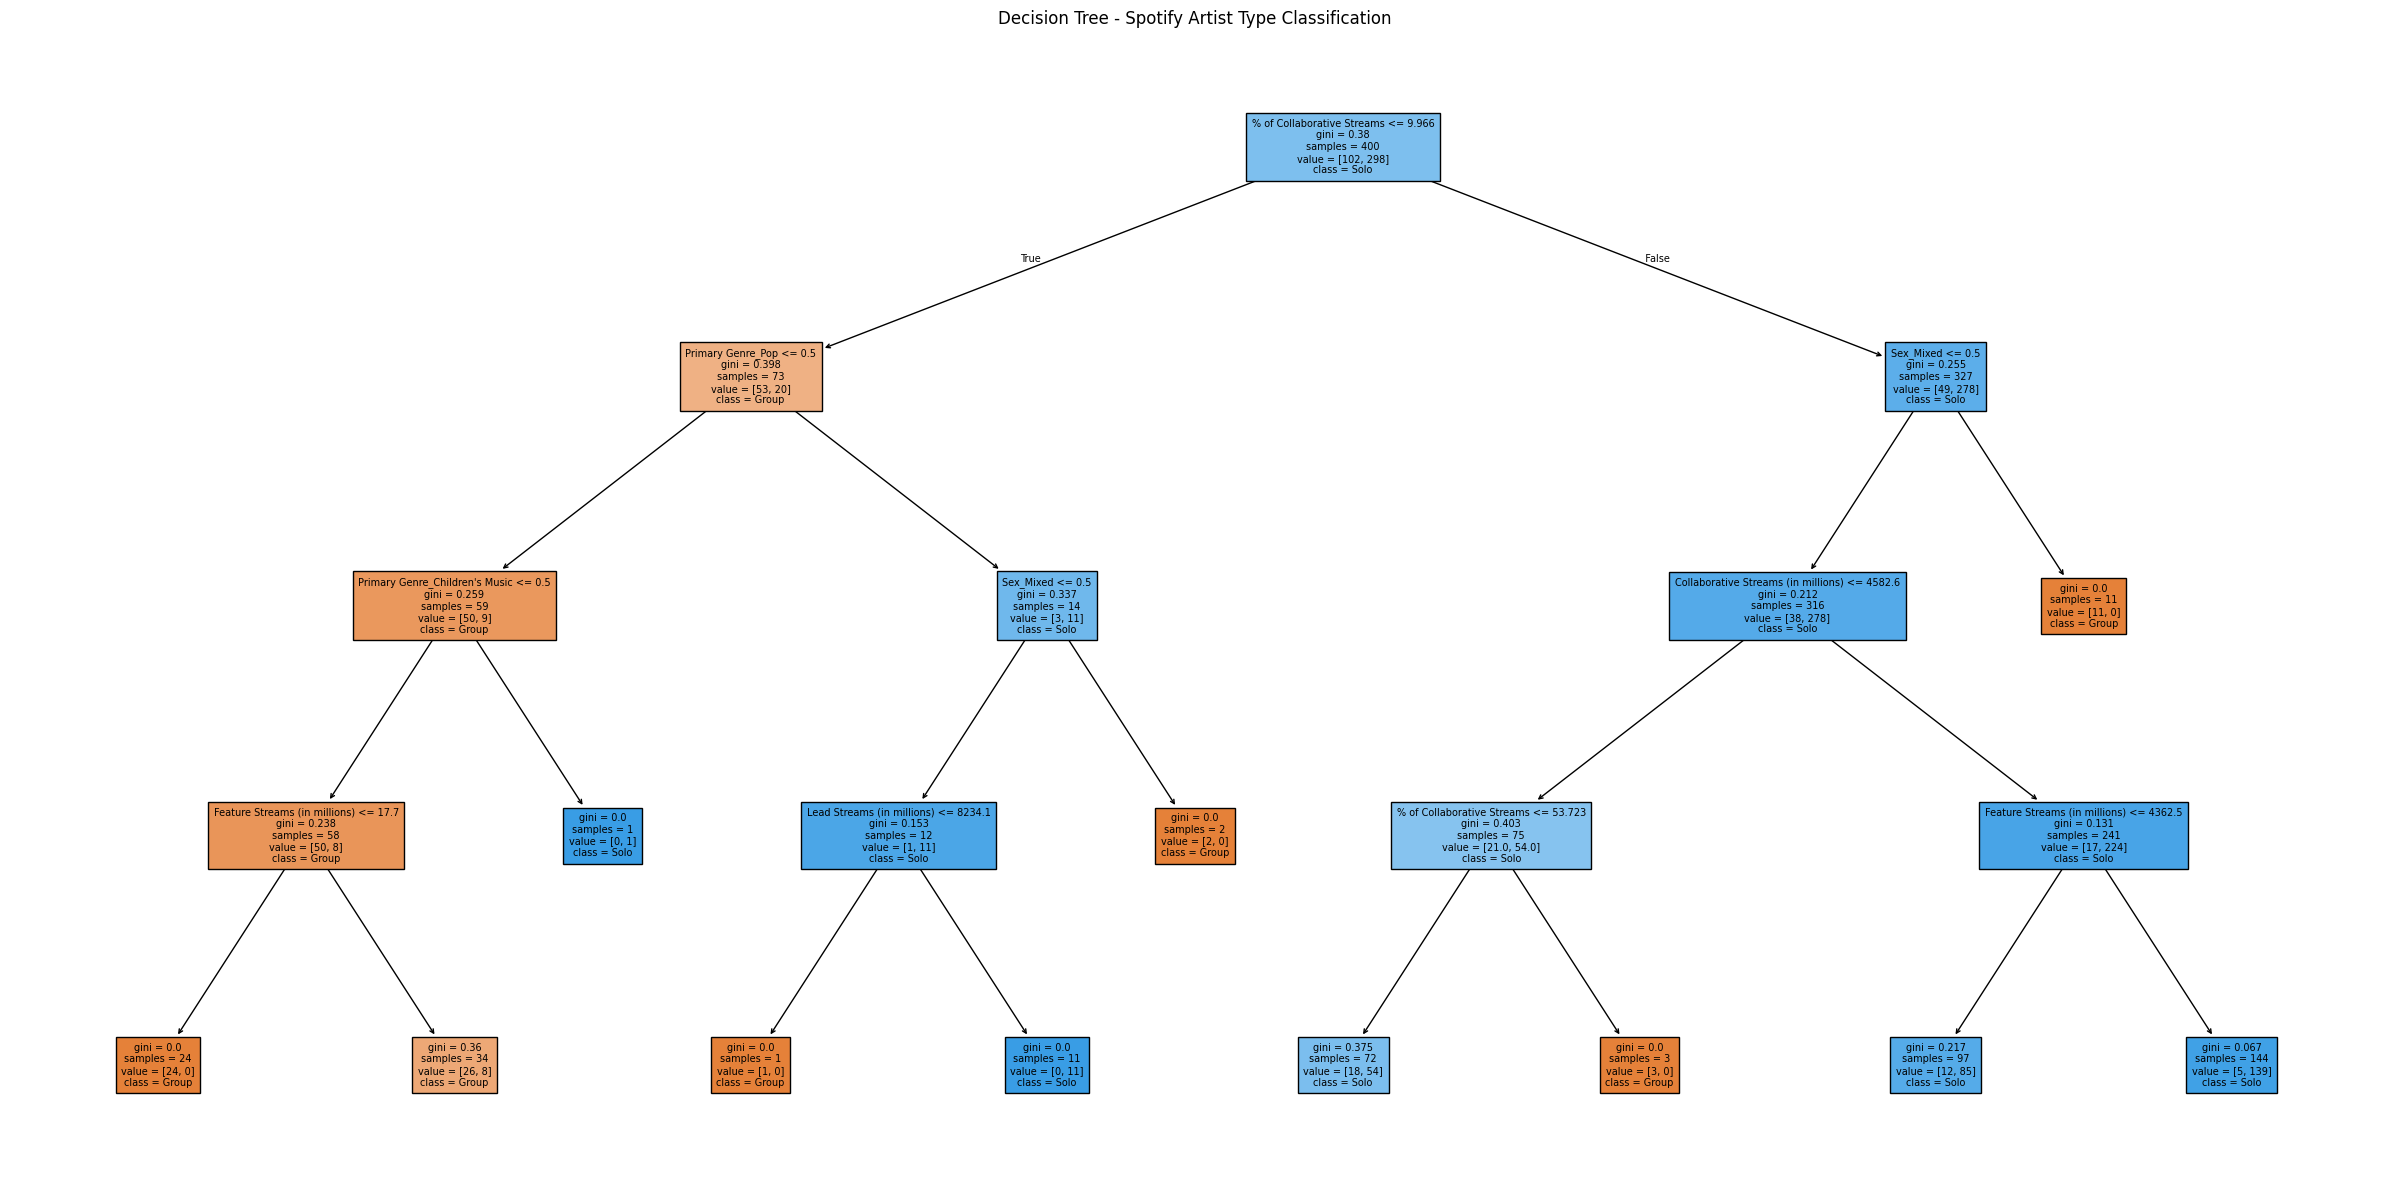

In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt

# =========================================================
# 0. MOUNT GOOGLE DRIVE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# 1. LOAD SPOTIFY DATASET
# =========================================================

df = pd.read_csv(
    '/content/drive/MyDrive/Colab/Most Streamed Artists on Spotify.csv'
)

# Strip leading/trailing whitespaces from column names to fix the KeyError
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


# =========================================================
# 2. HANDLE MISSING VALUES
# =========================================================

for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):

        df[col] = df[col].fillna(
            df[col].median()
        )

    else:

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )


# =========================================================
# 3. ENCODE CATEGORICAL VARIABLES
# =========================================================

categorical_cols = [
    'Sex',
    'Country of Origin',
    'Primary Language',
    'Primary Genre'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)


# =========================================================
# 4. DEFINE FEATURES AND TARGET
# =========================================================

# Artist Type is our classification target.
# We must also drop non-numeric identifier columns like 'Artist Name' so models can train.
X = df_encoded.drop(
    columns=['Artist Type', 'Artist Name']
)

y = df_encoded['Artist Type']


# =========================================================
# 5. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)


print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# =========================================================
# 6. CREATE DECISION TREE
# =========================================================

model = DecisionTreeClassifier(

    max_depth=4,

    random_state=42
)


# =========================================================
# 7. TRAIN MODEL
# =========================================================

model.fit(
    X_train,
    y_train
)


# =========================================================
# 8. MAKE PREDICTIONS
# =========================================================

y_pred = model.predict(
    X_test
)


# =========================================================
# 9. EVALUATE MODEL
# =========================================================

print("\n======================================")
print("DECISION TREE RESULTS")
print("======================================")

print(
    "\nAccuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)


# =========================================================
# 10. PLOT DECISION TREE
# =========================================================

plt.figure(
    figsize=(24, 12)
)

plot_tree(

    model,

    feature_names=X.columns,

    class_names=[
        str(c)
        for c in model.classes_
    ],

    filled=True,

    fontsize=7
)

plt.title(
    "Decision Tree - Spotify Artist Type Classification"
)

plt.tight_layout()


# =========================================================
# 11. SAVE TREE IMAGE
# =========================================================

plt.savefig(
    'spotify_decision_tree.png',
    dpi=150,
    bbox_inches='tight'
)

print(
    "\nSaved tree image -> "
    "spotify_decision_tree.png"
)

plt.show()

In [7]:
"""
Simple Random Forest Example - Spotify Dataset
===============================================
Train a Random Forest to predict Artist Type,
check accuracy, OOB score, classification report,
and feature importances.
"""

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42

# ---------------------------------------------------------------------
# 1. Load the Spotify dataset
# ---------------------------------------------------------------------
df = pd.read_csv(
    "/content/drive/MyDrive/Colab/Most Streamed Artists on Spotify.csv"
)

# Fix leading/trailing whitespaces in column names
df.columns = df.columns.str.strip()

print("Sample of the dataset:")
print(df.head())

print(f"\nDataset shape: {df.shape}")
print(f"\nClass balance:")
print(df["Artist Type"].value_counts())

# ---------------------------------------------------------------------
# 2. Handle missing values
# ---------------------------------------------------------------------
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# ---------------------------------------------------------------------
# 3. Encode categorical variables
# ---------------------------------------------------------------------
categorical_cols = [
    "Sex",
    "Country of Origin",
    "Primary Language",
    "Primary Genre"
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

# ---------------------------------------------------------------------
# 4. Define features and target
# ---------------------------------------------------------------------
TARGET = "Artist Type"

# Drop BOTH target and the non-numeric text column 'Artist Name'
X = df_encoded.drop(columns=[TARGET, 'Artist Name'])
y = df_encoded[TARGET]

feature_names = X.columns.tolist()

# ---------------------------------------------------------------------
# 5. Train / test split
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# ---------------------------------------------------------------------
# 6. Train a Random Forest
# ---------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

# ---------------------------------------------------------------------
# 7. Evaluate
# ---------------------------------------------------------------------
y_pred = rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("\n======================================")
print("RANDOM FOREST RESULTS")
print("======================================")

print(f"\nOOB score: {rf.oob_score_:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------------------
# 8. Feature importances
# ---------------------------------------------------------------------
print("\nFeature importances:")

for name, importance in sorted(
    zip(feature_names, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"  {name}: {importance:.4f}")

Sample of the dataset:
     Artist Name     Sex Country of Origin Primary Language Primary Genre  \
0          Drake    Male            Canada          English       Hip-Hop   
1   Taylor Swift  Female     United States          English           Pop   
2      Bad Bunny    Male     United States          Spanish     Reggaeton   
3     The Weeknd    Male            Canada          English           R&B   
4  Justin Bieber    Male            Canada          English           Pop   

  Artist Type  Debut Year  Total Streams (in millions)  \
0        Solo        2006                     137492.1   
1        Solo        2006                     127861.0   
2        Solo        2013                     125899.8   
3        Solo        2009                      95703.2   
4        Solo        2009                      78104.4   

   Lead Streams (in millions)  Feature Streams (in millions)  \
0                     94851.1                        42640.9   
1                    126177.3        

In [8]:
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE,
)